# multi-output neural network

In [3]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# If you want to check details about the GPU
# print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
Num GPUs Available: 1


In [5]:
# installer les packages necessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# charger le dataset
pizza_types = pd.read_csv('/content/pizza_types.csv', index_col=0)

In [8]:
pizza_types.head(10)

,corn,olives,mushrooms,spinach,pineapple,artichoke,chilli,pepper,onion,mozzarella,egg,pepperoni,beef,chicken,bacon,vegan,vegetarian,meaty
0,False,True,False,True,False,False,True,False,False,False,True,True,True,False,False,False,False,True
1,True,False,False,True,False,False,True,False,False,True,False,True,True,True,False,False,False,True
2,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False,False,True
3,False,True,True,False,False,False,True,False,False,True,False,True,True,False,False,False,False,True
4,False,True,False,False,True,True,False,False,False,True,True,True,True,False,False,False,False,True
5,False,False,False,False,True,False,False,True,True,False,True,True,False,False,False,False,False,True
6,False,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,True
7,True,False,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,True
8,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True
9,True,False,False,False,False,False,True,True,False,True,False,False,True,True,False,False,False,True


In [9]:
pizza_types.shape

(5520, 18)

Let's split them into an 80% training dataset and a 20% testing dataset.

In [10]:
training_dataset = pizza_types.sample(frac=0.8)
testing_dataset = pizza_types[~pizza_types.index.isin(training_dataset.index)]

In [11]:
# chek to see if the splitv was done directly
training_dataset.shape

(4416, 18)

In [12]:
testing_dataset.shape

(1104, 18)

Set Up and Train Your First Multi-Output Neural Network

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

pizza_type_model = Sequential()
pizza_type_model.add(Dense(3, input_dim=15, activation='softmax'))

sgd = SGD()

pizza_type_model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

pizza_type_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

Training your data

In [15]:
history_sgd_pizza_type_model = pizza_type_model.fit(
    training_dataset[['corn', 'olives', 'mushrooms', 'spinach', 'pineapple', 'artichoke', 'chilli', 'pepper', 'onion', 'mozzarella', 'egg', 'pepperoni', 'beef', 'chicken', 'bacon',]],
    training_dataset[['vegan', 'vegetarian', 'meaty']],
    epochs=200,
    validation_split=0.2,
)

Epoch 1/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4025 - loss: 1.1766 - val_accuracy: 0.9140 - val_loss: 0.4612
Epoch 2/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9118 - loss: 0.4158 - val_accuracy: 0.9186 - val_loss: 0.3225
Epoch 3/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9111 - loss: 0.3233 - val_accuracy: 0.9186 - val_loss: 0.2843
Epoch 4/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9046 - loss: 0.3134 - val_accuracy: 0.9186 - val_loss: 0.2664
Epoch 5/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9033 - loss: 0.2978 - val_accuracy: 0.9186 - val_loss: 0.2553
Epoch 6/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9052 - loss: 0.2833 - val_accuracy: 0.9186 - val_loss: 0.2469
Epoch 7/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9164 - loss: 0.2551 - val_accuracy: 0.9186 - val_loss: 0.2400
Epoch 8/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9164 - loss: 0.2471 - val_acc

Evaluate the model

In [16]:
test_loss, test_acc = pizza_type_model.evaluate(
    testing_dataset[['corn', 'olives', 'mushrooms', 'spinach', 'pineapple', 'artichoke', 'chilli', 'pepper', 'onion', 'mozzarella', 'egg', 'pepperoni', 'beef', 'chicken', 'bacon',]],
    testing_dataset[['vegan', 'vegetarian', 'meaty']]
)

print(f"Evaluation result on Test Data : Loss = {test_loss}, accuracy = {test_acc}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0492
Evaluation result on Test Data : Loss = 0.048998259007930756, accuracy = 1.0


change the optimizer SGD(stochastic gradient descent ) and use Adam. Whereas SGD maintained its learning rate during the training session, Adam varies it based on how the algorithm is learning, making training much faster.

In [17]:
from tensorflow.keras.optimizers import Adam

In [18]:
pizza_type_model = Sequential()

pizza_type_model.add(Dense(3, input_dim=15, activation='softmax'))

adam = Adam()

pizza_type_model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

pizza_type_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_adam_pizza_type_model = pizza_type_model.fit(
    training_dataset[['corn', 'olives', 'mushrooms', 'spinach', 'pineapple', 'artichoke', 'chilli', 'pepper', 'onion', 'mozzarella', 'egg', 'pepperoni', 'beef', 'chicken', 'bacon',]],
    training_dataset[['vegan', 'vegetarian', 'meaty']],
    epochs=200,
    validation_split=0.2,
)

Epoch 1/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5174 - loss: 0.9793 - val_accuracy: 0.8416 - val_loss: 0.5882
Epoch 2/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8447 - loss: 0.5555 - val_accuracy: 0.9174 - val_loss: 0.4019
Epoch 3/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8982 - loss: 0.4100 - val_accuracy: 0.9186 - val_loss: 0.3355
Epoch 4/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9073 - loss: 0.3410 - val_accuracy: 0.9186 - val_loss: 0.3047
Epoch 5/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9119 - loss: 0.3051 - val_accuracy: 0.9186 - val_loss: 0.2858
Epoch 6/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9138 - loss: 0.2883 - val_accuracy: 0.9186 - val_loss: 0.2716
Epoch 7/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9089 - loss: 0.2843 - val_accuracy: 0.9186 - val_loss: 0.2595
Epoch 8/200
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9145 - loss: 0.2628 - val_acc

Let's compare the training history when using SGD and Adam:

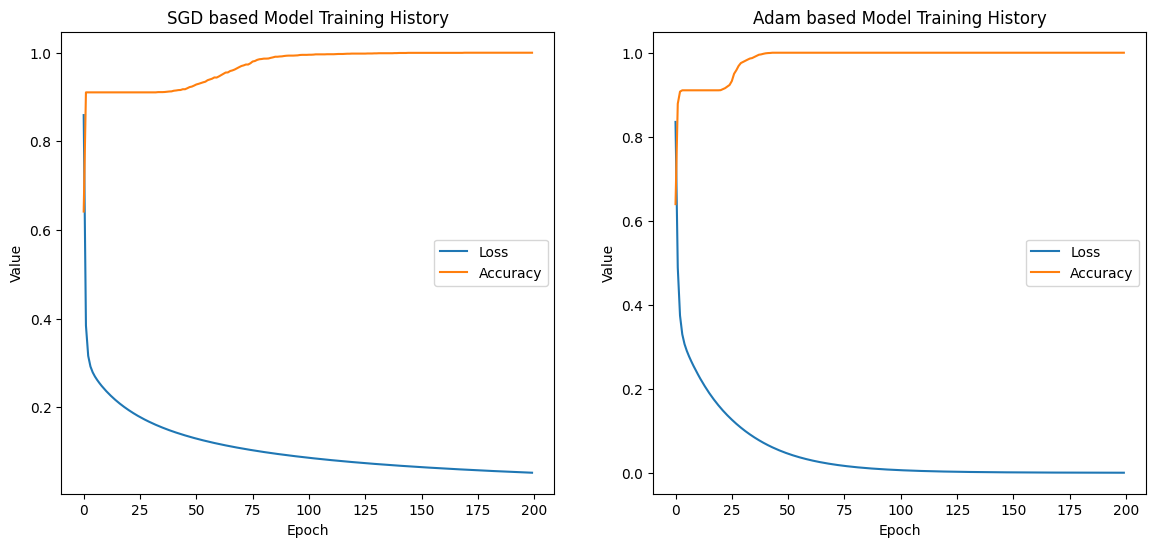

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes = axes.flatten()

axes[0].plot(history_sgd_pizza_type_model.history['loss'])
axes[0].plot(history_sgd_pizza_type_model.history['accuracy'])
axes[0].set_title('SGD based Model Training History')
axes[0].set_ylabel('Value')
axes[0].set_xlabel('Epoch')
axes[0].legend(['Loss', 'Accuracy'], loc='center right')
axes[1].plot(history_adam_pizza_type_model.history['loss'])
axes[1].plot(history_adam_pizza_type_model.history['accuracy'])
axes[1].set_title('Adam based Model Training History')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Epoch')
axes[1].legend(['Loss', 'Accuracy'], loc='center right')
plt.show()

Loss (the blue line) - with SGD, it reaches 0 after approximately 200 iterations; however, when using Adam, it reaches 0 after around 100 iterations.

# Train a Deeper Fully Connected Neural Network

In [22]:
traffic_data = pd.read_csv('/content/traffic_data.csv', index_col=0)

In [23]:
traffic_data.head()

,day,minute,hour,second,type
0,Monday,0,8,14,traffic
1,Monday,0,8,28,traffic
2,Monday,0,8,34,traffic
3,Monday,0,8,45,traffic
4,Monday,0,8,53,traffic


In [25]:
traffic_data.shape

(85638, 5)

In [26]:
traffic_data['type'].value_counts()

,count
type,
no_traffic,50769
traffic,34869


The dataset is imbalanced; there is more data when there is no traffic, but you will manage!

In [27]:
traffic_data['day'].value_counts()

,count
day,
Sunday,12278
Saturday,12251
Thursday,12241
Wednesday,12237
Tuesday,12217
Monday,12212
Friday,12202


There is a relatively equal representation of data every day. How about the traffic vs. non-traffic variable per day?

In [28]:
traffic_data.groupby('day')['type'].value_counts()

day        type      
Friday     traffic        6989
           no_traffic     5213
Monday     traffic        6972
           no_traffic     5240
Saturday   no_traffic    12251
Sunday     no_traffic    12278
Thursday   traffic        6965
           no_traffic     5276
Tuesday    traffic        6990
           no_traffic     5227
Wednesday  traffic        6953
           no_traffic     5284
Name: count, dtype: int64

There is a relatively equal traffic vs. no-traffic representation besides Saturdays and Sundays. What about per hour?

In [29]:
traffic_data['hour'].value_counts()

,count
hour,
8,6211
16,6204
20,6195
18,6188
14,6180
10,6156
12,6147
15,6110
17,6076


In [30]:
traffic_data['c_type'] = traffic_data['type'].apply(lambda x: 1 if x == 'traffic' else 0)

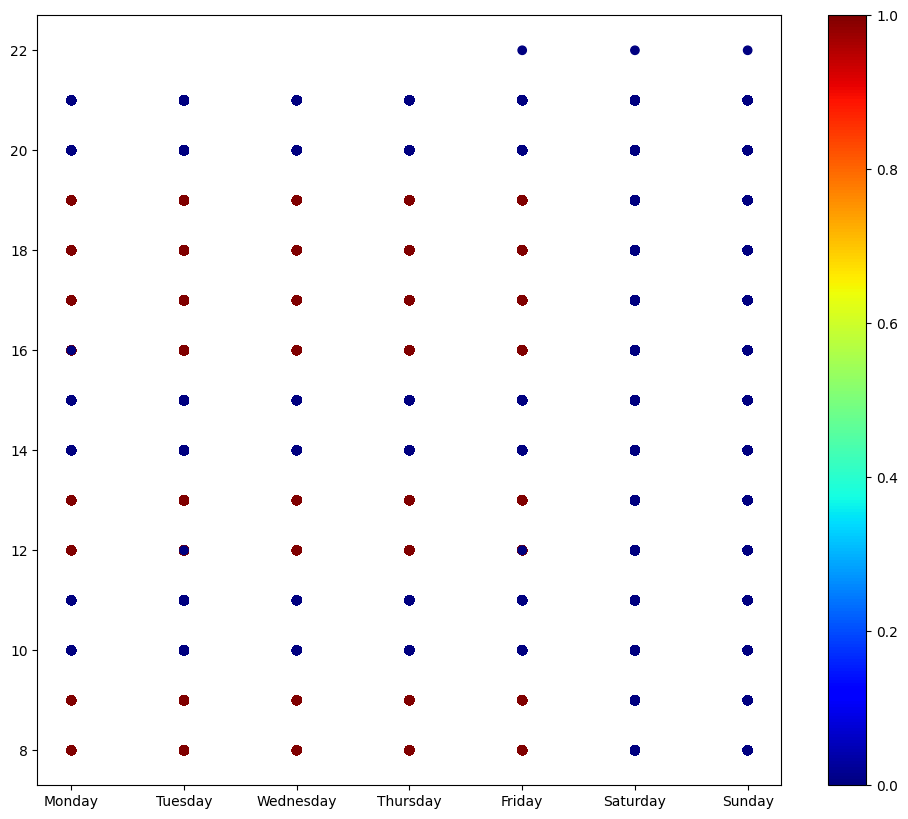

In [34]:
# visualize data
import matplotlib.pyplot as plt

from matplotlib.pyplot import colorbar, figure

figure(num=None, figsize=(12, 10))

plt.scatter(
    traffic_data['day'],
    traffic_data['hour'],
    c=traffic_data['c_type'],
    cmap='jet'
)

cbar = colorbar()

As seen before, there is no traffic on Saturdays or Sundays. It seems to be mostly around some key hours, such as 8-10, 12-13, and 16-20.

Let's first convert the days to new columns using one-hot encoding:

In [35]:
traffic_data = traffic_data.join(pd.get_dummies(traffic_data['day']))

Split the data again into a training and test set:

In [36]:
training_dataset = traffic_data.sample(frac=0.8)
testing_dataset = traffic_data[~traffic_data.index.isin(training_dataset.index)]

In [43]:
# select the input columns you will be using
input_columns = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'hour', 'minute','second']

Set Up Your First Neural Network With a Hidden Layer

Use ReLu function because deep neural networks can suffer from a phenomenon called gradient vanishing.  

Gradient vanishing is a phenomenon that happens when the error that backpropagation pushes back throughout the network gets smaller and smaller as it moves from right to left (output layer towards input layer).

In [38]:
from tensorflow.keras.layers import Dropout

In [45]:
traffic_model = Sequential([
    Dense(30, input_dim=len(input_columns), activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

adam = Adam()

traffic_model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

traffic_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,355 (5.29 KB)

 Trainable params: 1,355 (5.29 KB)

 Non-trainable params: 0 (0.00 B)

The batch size represents how many examples the algorithm predicts during training before the weights get updated.

In [46]:
batch_size = 100

In [48]:
history_traffic_model = traffic_model.fit(
   training_dataset[input_columns].astype(int),
   training_dataset[['c_type']],
   epochs=30,
   validation_split=0.1,
   batch_size=batch_size
)

Epoch 1/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5445 - loss: 0.9650 - val_accuracy: 0.6037 - val_loss: 0.6403
Epoch 2/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6146 - loss: 0.6275 - val_accuracy: 0.6992 - val_loss: 0.5071
Epoch 3/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6803 - loss: 0.5177 - val_accuracy: 0.6993 - val_loss: 0.4828
Epoch 4/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6867 - loss: 0.4969 - val_accuracy: 0.7238 - val_loss: 0.4712
Epoch 5/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7064 - loss: 0.4836 - val_accuracy: 0.7265 - val_loss: 0.4694
Epoch 6/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7349 - loss: 0.4687 - val_accuracy: 0.7802 - val_loss: 0.4328
Epoch 7/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7603 - loss: 0.4412 - val_accuracy: 0.7790 - val_loss: 0.3947
Epoch 8/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7715 - loss: 0.4069 - val_accuracy: 0.

Evaluate the model

In [50]:
test_loss_traffic, test_acc_traffic = traffic_model.evaluate(
    testing_dataset[input_columns].astype(int),
    testing_dataset[['c_type']]
)

print(f"Evaluation result on Test Data: Loss = {test_loss_traffic}, accuracy = {test_acc_traffic}")

536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9781 - loss: 0.1244
Evaluation result on Test Data: Loss = 0.10505125671625137, accuracy = 0.9767048358917236


# Convolutionnal neural network (CNN)

In [59]:
import zipfile

zip_path = "/content/datasets.zip"   # ← Mets le nom de ton ZIP

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.printdir()

File Name                                             Modified             Size
datasets/                                      2020-09-02 16:14:52            0
datasets/pizza_types.csv                       2020-09-02 16:14:52       585084
datasets/recipes/                              2020-09-02 16:14:52            0
datasets/recipes/data_pizza.npy                2020-09-02 16:14:52       242039
datasets/recipes/license.txt                   2020-09-02 16:14:52         1056
datasets/shapes/                               2020-09-02 16:14:52            0
datasets/shapes/circle/                        2020-09-02 16:14:52            0
datasets/shapes/circle/0.png                   2020-09-02 16:14:52         1446
datasets/shapes/circle/1.png                   2020-09-02 16:14:52         1437
datasets/shapes/circle/10.png                  2020-09-02 16:14:52         1451
datasets/shapes/circle/100.png                 2020-09-02 16:14:52         1438
datasets/shapes/circle/1000.png         

In [68]:
import zipfile
import os

zip_path = "/content/datasets.zip"        # remplace par le nom exact de ton zip uploadé
folder_to_extract = "/content/datasets/shapes/"   # dossier à extraire
output_path = "/data/shapes"         # dossier de destination local dans Colab

os.makedirs(output_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for member in zip_ref.namelist():
        if member.startswith(folder_to_extract):
            # On extrait en conservant l'arborescence relative après "datasets/shapes/"
            # donc pour member="datasets/shapes/triangle/83.png"
            # on extrait dans "data/shapes/triangle/83.png"
            relative_path = member[len(folder_to_extract):]
            target_path = os.path.join(output_path, relative_path)

            # création des dossiers nécessaires
            os.makedirs(os.path.dirname(target_path), exist_ok=True)

            with zip_ref.open(member) as source, open(target_path, "wb") as target:
                target.write(source.read())

print("Extraction terminée ! Voici les classes extraites :")

# Liste des classes dans shapes (les dossiers dans data/shapes)
classes = [d for d in os.listdir(output_path) if os.path.isdir(os.path.join(output_path, d))]
print(classes)


Extraction terminée ! Voici les classes extraites :
[]


In [70]:
import zipfile
import os

zip_path = "/content/datasets.zip"
folder_to_extract = "datasets/shapes/"
output_path = "data/shapes"

os.makedirs(output_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    members = [m for m in zip_ref.namelist() if m.startswith(folder_to_extract)]
    print(f"Fichiers à extraire ({len(members)}):")
    for m in members[:10]:
        print(" ", m)

    for member in members:
        if zip_ref.getinfo(member).is_dir(): # Skip directories
            continue
        relative_path = member[len(folder_to_extract):]
        if not relative_path:
            continue
        target_file_path = os.path.join(output_path, relative_path)
        os.makedirs(os.path.dirname(target_file_path), exist_ok=True)
        with zip_ref.open(member) as source, open(target_file_path, "wb") as target:
            target.write(source.read())

print("Extraction terminée !")

classes = [d for d in os.listdir(output_path) if os.path.isdir(os.path.join(output_path, d))]
print("Classes extraites :", classes)

Fichiers à extraire (14975):
  datasets/shapes/
  datasets/shapes/circle/
  datasets/shapes/circle/0.png
  datasets/shapes/circle/1.png
  datasets/shapes/circle/10.png
  datasets/shapes/circle/100.png
  datasets/shapes/circle/1000.png
  datasets/shapes/circle/1001.png
  datasets/shapes/circle/1002.png
  datasets/shapes/circle/1003.png
Extraction terminée !
Classes extraites : ['star', 'circle', 'triangle', 'square']


In [74]:
working_dir = 'data/shapes'

In [71]:
classes = ['circle', 'square', 'star', 'triangle']

In [72]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [73]:
data_generator = ImageDataGenerator(validation_split=0.2)

In [75]:
training_generator = data_generator.flow_from_directory(
    working_dir,
    classes=classes,
    batch_size=100,
    subset='training',
   color_mode='grayscale'
)

Found 11976 images belonging to 4 classes.


In [80]:
validation_generator = data_generator.flow_from_directory(
working_dir,
    classes=classes,
    batch_size=100,
    subset='validation',
    color_mode='grayscale'
)

Found 2994 images belonging to 4 classes.


In [81]:
validation_generator = data_generator.flow_from_directory(
    working_dir,
    classes=classes,
    batch_size=100,
    subset='validation',
    color_mode='grayscale'
)

Found 2994 images belonging to 4 classes.


Now check the images to see what they look like:

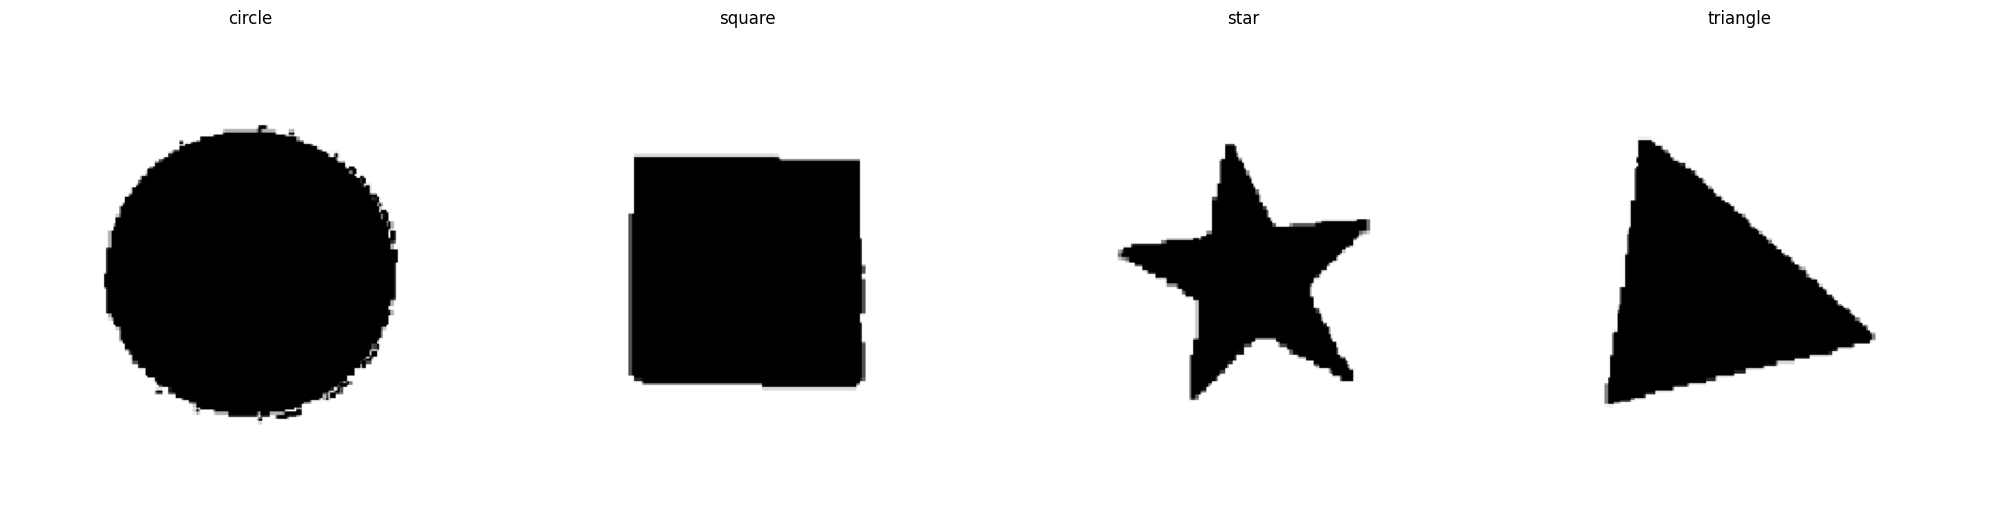

In [84]:
import matplotlib.pyplot as plt

images, labels = next(training_generator)

fig, axes = plt.subplots(1, 4, figsize=(20,20))

axes = axes.flatten()
axes_idx = 0

for one_hot_label in range(4):
    for image, label in zip(images, labels):
        if label[one_hot_label] == 1:
            ax = axes[axes_idx]
            ax.imshow(image[:,:,0], cmap='Greys_r')
            ax.axis('off')
            ax.set_title(classes[one_hot_label])
            axes_idx += 1
            break

plt.tight_layout()

plt.show()

Select one and let's take a look:

In [86]:
first_image_in_batch = images[0]

In [87]:
image_shape = first_image_in_batch.shape

print(image_shape)

(256, 256, 1)


It has 256 pixels x 256 pixels. We can also see that when we plot it:

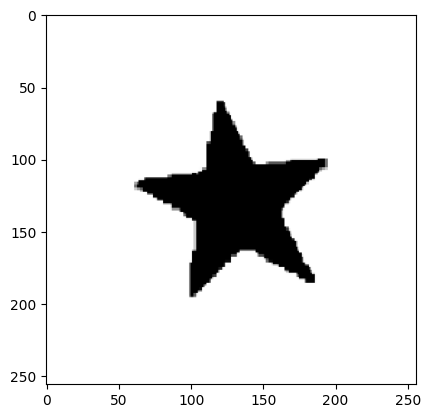

In [88]:
plt.imshow(first_image_in_batch[:,:,0], cmap='Greys_r')

In [89]:
print(first_image_in_batch[:,:,0])

[[255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 ...
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]]


Set Up Your First Convolutional Neural Network


In [90]:
from keras.layers import Conv2D

In [91]:
convolutional_layer = Conv2D(16, (5, 5), activation='relu', input_shape=image_shape)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resulting image size = (number of rows in the image) - (number of rows in the filter - 1).
256 - 5 + 1 = 252



In [92]:
from keras.layers import MaxPool2D

max_pool_layer = MaxPool2D()

In [93]:
from keras.layers import Flatten

flatten_layer = Flatten()

In [94]:
from keras.layers import Dense

dense_layer = Dense(4, activation='softmax')

build the model:

In [95]:
from keras.models import Sequential

cnn_model = Sequential([
    convolutional_layer,
    max_pool_layer,
    flatten_layer,
    dense_layer
])


cnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 252, 252, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 254016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │     1,016,068 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,016,484 (3.88 MB)

 Trainable params: 1,016,484 (3.88 MB)

 Non-trainable params: 0 (0.00 B)

There are approximately 1 million parameters to train now. Most of these are in the output layer as it needs to process the results from the flatten layer.

start training:

In [96]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history = cnn_model.fit(training_generator, epochs=5)

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.6443 - loss: 2664.9802
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.9946 - loss: 1.1098
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9980 - loss: 0.2131
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.9995 - loss: 0.0275
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.9999 - loss: 0.0046


In [97]:
val_loss, val_acc = cnn_model.evaluate(validation_generator)

print(f"Evaluation result on Test Data : Loss = {val_loss}, accuracy = {val_acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9979 - loss: 0.2766
Evaluation result on Test Data : Loss = 0.12447729706764221, accuracy = 0.9983299970626831


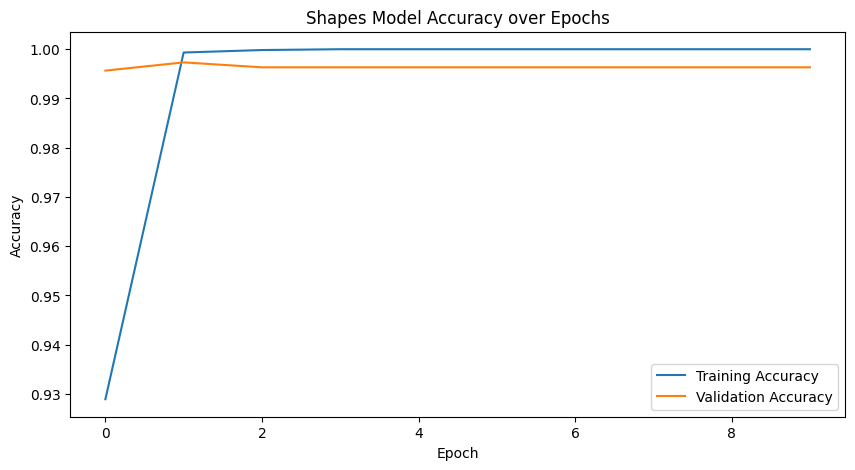

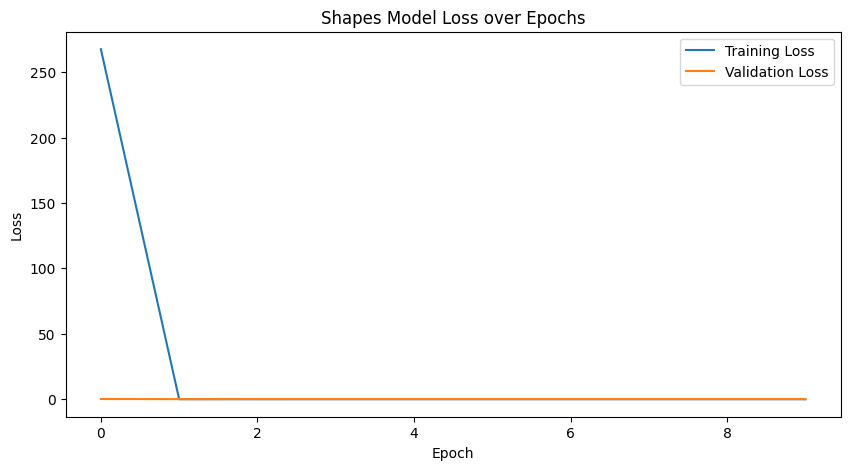

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_shapes_model.history['accuracy'], label='Training Accuracy')
plt.plot(history_shapes_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Shapes Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_shapes_model.history['loss'], label='Training Loss')
plt.plot(history_shapes_model.history['val_loss'], label='Validation Loss')
plt.title('Shapes Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


# Define the CNN model
shapes_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='softmax') # Output layer for 4 classes
])

# Compile the model
shapes_model.compile(optimizer=Adam(),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

shapes_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,509,508 (120.20 MB)

 Trainable params: 31,509,508 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
validation_generator = data_generator.flow_from_directory(
    working_dir,
    classes=classes,
    batch_size=100,
    subset='validation',
    color_mode='grayscale'
)

Found 2994 images belonging to 4 classes.


In [78]:
history_shapes_model = shapes_model.fit(
    training_generator,
    epochs=10, # You can adjust the number of epochs
    validation_data=validation_generator
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 291ms/step - accuracy: 0.7794 - loss: 1005.7595 - val_accuracy: 0.9957 - val_loss: 0.1662
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.9991 - loss: 0.0109 - val_accuracy: 0.9973 - val_loss: 0.0795
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.9998 - loss: 5.0866e-04 - val_accuracy: 0.9963 - val_loss: 0.1452
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 1.0000 - loss: 2.4867e-06 - val_accuracy: 0.9963 - val_loss: 0.1398
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 1.0000 - loss: 1.1600e-07 - val_accuracy: 0.9963 - val_loss: 0.1398
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 1.0000 - loss: 1.3279e-07 - val_accuracy: 0.9963 - val_loss: 0.1398
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 1.0000 - loss: 2.8068e-08 - val_accuracy: 0.9963 - val_loss: 0.1398
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 167ms/step - accuracy: 1.00

# Recurrent Neural Networks

In [99]:
import numpy as np
data_pizza = np.load("/content/data_pizza.npy", allow_pickle=True)

In [100]:
data_pizza.shape

(200,)

In [101]:
from pprint import pprint
for entry in data_pizza[0:3]:
    pprint(entry)


{'categories': ['pizza'],
 'directions': ['Preheat oven to 400 degrees F (200 degrees C). Grease a 9x13 '
                'inch baking dish. Place ground beef in a large, deep skillet. '
                'Cook over medium high heat until evenly brown. Stir in '
                'pepperoni, and cook until browned. Drain excess fat. Stir in '
                'pizza sauce. Remove from heat, and set aside.',
                'Cut biscuits into quarters, and place in the bottom of baking '
                'dish. Spread meat mixture evenly over the biscuits. Sprinkle '
                'top with onion, olives and mushrooms.',
                'Bake uncovered in preheated oven for 20 to 25 minutes. '
                'Sprinkle top with mozzarella and Cheddar cheese. Bake an '
                'additional 5 to 10 minutes, until cheese is melted. Let stand '
                '10 minutes before serving.'],
 'ingredients': [[1, '', 'beef', ''],
                 [0.25, '', 'sausage', 'sliced'],
          

You only care about the ingredients, right? So just extract those.

In [102]:
ingredients_only = [t['ingredients'] for t in data_pizza]

In [106]:
ingredients_only[0]

[[1, '', 'beef', ''],
 [0.25, '', 'sausage', 'sliced'],
 [1, '', 'sauce', ''],
 [2, '', 'buttermilk', 'refrigerated'],
 [0.5, '', 'onion', 'sliced_separated'],
 [1, '', 'black', 'sliced'],
 [1, '', 'mushroom', 'sliced'],
 [1.5, '', 'mozzarella_cheese', 'shredded'],
 [1, '', 'cheese', 'shredded']]

Now create a single string per pizza recipe from these ingredients:

In [107]:
joined_ingredients = []

for set_of_ingredients in ingredients_only:
    str_ingredients = ''
    for ingredient in set_of_ingredients:
      str_ingredients += ' '.join([str(t) for t in ingredient]) + ' '
    joined_ingredients.append(str_ingredients.replace('· ', ' '))

In [108]:
joined_ingredients[0]

'1  beef  0.25  sausage sliced 1  sauce  2  buttermilk refrigerated 0.5  onion sliced_separated 1  black sliced 1  mushroom sliced 1.5  mozzarella_cheese shredded 1  cheese shredded '

Now make it simpler and join up all the text in one large part:

In [109]:
text = ' '.join(joined_ingredients).lower()

## Create Batches of Data

* step 1 : Convert the joined ingredients into a list of numbers:

In [110]:
vocabulary = sorted(set(text))

character_to_number = {}

for idx, character in enumerate(vocabulary):
    character_to_number[character] = idx

number_to_character = np.array(vocabulary)

print(f'There are {len(vocabulary)} different characters in the vocabulary')

There are 39 different characters in the vocabulary


In [111]:
character_to_number

{' ': 0,
 '.': 1,
 '0': 2,
 '1': 3,
 '2': 4,
 '3': 5,
 '4': 6,
 '5': 7,
 '6': 8,
 '7': 9,
 '8': 10,
 '9': 11,
 '_': 12,
 'a': 13,
 'b': 14,
 'c': 15,
 'd': 16,
 'e': 17,
 'f': 18,
 'g': 19,
 'h': 20,
 'i': 21,
 'j': 22,
 'k': 23,
 'l': 24,
 'm': 25,
 'n': 26,
 'o': 27,
 'p': 28,
 'q': 29,
 'r': 30,
 's': 31,
 't': 32,
 'u': 33,
 'v': 34,
 'w': 35,
 'x': 36,
 'y': 37,
 'z': 38}

* Convert the ingredients text to an array of numbers:

In [112]:
text_as_numbers = [character_to_number[character] for character in text]

In [113]:
print(f'"{text[:13]}" maps to:{text_as_numbers[:13]}')

"1  beef  0.25" maps to:[3, 0, 0, 14, 17, 17, 18, 0, 0, 2, 1, 4, 7]


* Step 2:
- Split the text into chunks.
-

In [114]:
chunk_length = 15

chunk_length_with_extra_character = chunk_length + 1

chunks = []

for idx in range(0, len(text_as_numbers), chunk_length_with_extra_character):
    chunks.append(text_as_numbers[idx:idx+chunk_length_with_extra_character])

print(f'You split the text into {len(chunks)} of {chunk_length} characters')

You split the text into 1992 of 15 characters


Let's check the chunks:

In [115]:
for number_chunk in chunks[:5]:
    text_chunk = [number_to_character[item] for item in number_chunk]
    print(f"Number sequence: {number_chunk}")
    print(f"As text: {''.join(text_chunk)}")
    print('')

Number sequence: [3, 0, 0, 14, 17, 17, 18, 0, 0, 2, 1, 4, 7, 0, 0, 31]
As text: 1  beef  0.25  s

Number sequence: [13, 33, 31, 13, 19, 17, 0, 31, 24, 21, 15, 17, 16, 0, 3, 0]
As text: ausage sliced 1 

Number sequence: [0, 31, 13, 33, 15, 17, 0, 0, 4, 0, 0, 14, 33, 32, 32, 17]
As text:  sauce  2  butte

Number sequence: [30, 25, 21, 24, 23, 0, 30, 17, 18, 30, 21, 19, 17, 30, 13, 32]
As text: rmilk refrigerat

Number sequence: [17, 16, 0, 2, 1, 7, 0, 0, 27, 26, 21, 27, 26, 0, 31, 24]
As text: ed 0.5  onion sl



* Step 3:
- convert all the chunks into input (x) and target (y) chunks

In [116]:
x = []
y = []

for chunk in chunks:
    x.append(chunk[:-1])
    y.append(chunk[1:])

In [117]:
print(f"Input chunk: {''.join([number_to_character[item] for item in x[0]])}")
print(f"Target chunk: {''.join([number_to_character[item] for item in y[0]])}")



Input chunk: 1  beef  0.25  
Target chunk:   beef  0.25  s


* Step 4
- create batches of these chunks

In [119]:
batched_x = []
batched_y = []

for idx in range(0, min(len(x), len(y)), batch_size):
    if (
        len(x[idx:idx+batch_size]) == batch_size and
        len(y[idx:idx+batch_size]) == batch_size
    ):
        batched_x.append(np.asarray(x[idx:idx+batch_size]))
        batched_y.append(np.asarray(y[idx:idx+batch_size]))

In [120]:
print(f'You have {len(batched_x)} batches of {len(batched_x[0])} '
      f'chunks of {len(batched_x[0][0])} characters each.')

You have 19 batches of 100 chunks of 15 characters each.


In [130]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model # Import Model for Functional API

def create_model(batch_size):
    # Define the input layer with a fixed batch_shape for stateful RNN
    inputs = Input(batch_shape=(batch_size, chunk_length))

    # Embedding layer
    embedded = Embedding(
        input_dim=len(vocabulary),
        output_dim=256,
    )(inputs) # Connect embedding to the input tensor

    # LSTM layer with stateful=True
    lstm_output = LSTM(
        units=256,
        return_sequences=True,
        stateful=True
    )(embedded) # Connect LSTM to embedding output

    # Output layer
    outputs = Dense(units=len(vocabulary), activation='softmax')(lstm_output)

    # Create the model using the Functional API
    rnn_model = Model(inputs=inputs, outputs=outputs)

    return rnn_model

In [150]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model # Import Model for Functional API

def create_model(batch_size):
    # Define the input layer with a fixed batch_shape for stateful RNN
    inputs = Input(batch_shape=(batch_size, chunk_length))

    # Embedding layer
    embedded = Embedding(
        input_dim=len(vocabulary),
        output_dim=256,
    )(inputs) # Connect embedding to the input tensor

    # LSTM layer with stateful=True
    lstm_output = LSTM(
        units=256,
        return_sequences=True,
        stateful=True
    )(embedded) # Connect LSTM to embedding output

    # Output layer
    outputs = Dense(units=len(vocabulary), activation='softmax')(lstm_output)

    # Create the model using the Functional API
    rnn_model = Model(inputs=inputs, outputs=outputs)

    return rnn_model

In [145]:
rnn_model = create_model(batch_size)

ValueError: Unrecognized keyword arguments passed to Embedding: {'batch_input_shape': [100, None]}

In [134]:
rnn_model = create_model(batch_size)
rnn_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (100, 15)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (100, 15, 256)         │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (100, 15, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (100, 15, 39)          │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,319 (2.08 MB)

 Trainable params: 545,319 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [147]:
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

In [149]:
import os

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_dir = './training_checkpoints'

checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True

)

start training:

In [151]:
import tensorflow as tf

x_full = np.concatenate(batched_x, axis=0)
y_full = np.concatenate(batched_y, axis=0)

# Create a tf.data.Dataset from your data
dataset = tf.data.Dataset.from_tensor_slices((x_full, y_full))
# Batch the dataset, ensuring drop_remainder=True for stateful LSTMs
dataset = dataset.batch(batch_size, drop_remainder=True)

# Recreate and recompile the model to ensure a clean state for tf.function tracing
rnn_model = create_model(batch_size)
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

history = rnn_model.fit(
    dataset,
    epochs=200,
    callbacks=[checkpoint_callback]
)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 3.4223
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7994
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.4298
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0494
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7547
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5591
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4289
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3323
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2581
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1973
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1459
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1017
Epoch 13/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0636
Epoch 14/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0302
Epoch 15/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0005
Epo

build new version

In [159]:
from tensorflow.train import latest_checkpoint
from tensorflow import TensorShape

latest_checkpoint = latest_checkpoint(checkpoint_dir)

single_input_rnn_model = create_model(batch_size=1)
single_input_rnn_model.load_weights(latest_checkpoint)
single_input_rnn_model.build(TensorShape([1, None]))

ValueError: File format not supported: filepath=None. Keras 3 only supports V3 `.keras` and `.weights.h5` files, or legacy V1/V2 `.h5` files.

To generate lists of ingredients, first determine the average size of a list of ingredients from your input data:



In [155]:
average_length_ingredients = np.mean([len(t) for t in joined_ingredients])

print(average_length_ingredients)

158.365


In [156]:
output_sequence_length = int(np.round(average_length_ingredients))

print(output_sequence_length)

158


In [157]:
starting_character = 'a'

now call the model:

In [ ]:
# convert starting character to a number and store it as a (batch, sample)
model_input = [[character_to_number[s] for s in starting_character]]

# store the generated text in here
generated_text = []

# reset the model
single_input_rnn_model.reset_states()

for i in range(output_sequence_length):
    predictions = single_input_rnn_model.predict(model_input)

    # np.argmax only returns the max of the predictions
    predicted_id = np.argmax(predictions)

    # use the predicted character as input now
    model_input = np.array([np.array([predicted_id])])

    generated_text.append(number_to_character[predicted_id])

print(starting_character + ''.join(generated_text))

As you can see, the ingredients are not perfect words! But humans can see some similarities to known words. The website team can't wait to set up the system. The chefs will be able to swap unclear ingredients with whatever they think works best. Will you also order one?